<a href="https://colab.research.google.com/github/tnwlvos/Purdue-AI-education-Muchine-Learning-/blob/main/FSSW_Audio_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FSSW 5-stage Audio Classification

연속 음향에서 다음 다섯 공정 단계를 분류하고 stage 전환 경계를 검출한다.

- OFF
- Approach
- Plunge
- Dwell
- Retract

모델 개발에는 development_A와 development_B만 사용한다. 실험 19~27의 test_holdout은 모델 구조와 학습 조건을 결정한 뒤 최종 평가에 한 번만 사용한다.

In [1]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


## 라이브러리 불러오기

음원 처리, Mel-spectrogram 생성, 데이터 관리 및 시각화에 필요한 라이브러리를 불러온다.

In [2]:
from pathlib import Path

import librosa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import soundfile as sf

## 프로젝트 경로와 stage 정보 설정

Google Drive 프로젝트 폴더, metadata, 연속 5-stage 음원과 앞으로 생성할 Log-Mel cache의 위치를 설정한다.

In [4]:
PROJECT_DIR = Path(
    "/content/drive/MyDrive/"
    "Friction Stir Spot Welding (FSSW)"
)

METADATA_DIR = (
    PROJECT_DIR / "[3] metadata"
)

SEQUENCE_DIR = (
    PROJECT_DIR
    / "[2] processed sound data"
    / "[6] continuous stage sequence"
)

FIVE_STAGE_MEL_DIR = (
    PROJECT_DIR
    / "[7] 5-stage mel spectrogram"
)

TIMELINE_MANIFEST_PATH = (
    METADATA_DIR
    / "timeline_manifest.csv"
)

STAGE_TO_ID = {
    "off": 0,
    "approach": 1,
    "plunge": 2,
    "dwell": 3,
    "retract": 4,
}

ID_TO_STAGE = {
    stage_id: stage_name
    for stage_name, stage_id
    in STAGE_TO_ID.items()
}

print(
    "프로젝트 폴더 존재:",
    PROJECT_DIR.exists(),
)

print(
    "연속 음원 폴더 존재:",
    SEQUENCE_DIR.exists(),
)

print(
    "타임라인 manifest 존재:",
    TIMELINE_MANIFEST_PATH.exists(),
)

프로젝트 폴더 존재: True
연속 음원 폴더 존재: True
타임라인 manifest 존재: True


## 5-stage 타임라인 manifest 불러오기

1초 window, 0.25초 hop으로 생성한 최종 타임라인 정보를 불러온다.

각 행에는 중심 시각의 stage, stage별 포함 비율, 경계 포함 여부와 경계 위치가 저장되어 있다.

In [5]:
timeline_manifest = pd.read_csv(
    TIMELINE_MANIFEST_PATH
)

print(
    "전체 윈도우 수:",
    len(timeline_manifest),
)

print(
    "전체 컬럼 수:",
    len(timeline_manifest.columns),
)

display(timeline_manifest.head())

전체 윈도우 수: 5260
전체 컬럼 수: 21


,timeline_window_id,experiment_id,dataset_role,relative_path,window_index,window_start_sec,window_end_sec,window_center_sec,center_stage,center_stage_id,...,target_approach,target_plunge,target_dwell,target_retract,boundary_present,boundary_index,from_stage,to_stage,boundary_sec,boundary_offset_sec
0,timeline_000001,1,development_A,[2] processed sound data/[6] continuous stage ...,0,0.00,1.00,0.50,off,0,...,0.0,0.0,0.0,0.0,False,-1,NaN,NaN,NaN,NaN
1,timeline_000002,1,development_A,[2] processed sound data/[6] continuous stage ...,1,0.25,1.25,0.75,off,0,...,0.0,0.0,0.0,0.0,False,-1,NaN,NaN,NaN,NaN
2,timeline_000003,1,development_A,[2] processed sound data/[6] continuous stage ...,2,0.50,1.50,1.00,off,0,...,0.0,0.0,0.0,0.0,False,-1,NaN,NaN,NaN,NaN
3,timeline_000004,1,development_A,[2] processed sound data/[6] continuous stage ...,3,0.75,1.75,1.25,off,0,...,0.0,0.0,0.0,0.0,False,-1,NaN,NaN,NaN,NaN
4,timeline_000005,1,development_A,[2] processed sound data/[6] continuous stage ...,4,1.00,2.00,1.50,off,0,...,0.0,0.0,0.0,0.0,False,-1,NaN,NaN,NaN,NaN


## 타임라인 데이터 검증

필수 컬럼, WAV 경로, 윈도우 길이, 중복 데이터와 분할별 stage 구성을 검사한다.

In [6]:
required_columns = [
    "timeline_window_id",
    "experiment_id",
    "dataset_role",
    "relative_path",
    "window_start_sec",
    "window_end_sec",
    "window_center_sec",
    "center_stage",
    "center_stage_id",
    "target_off",
    "target_approach",
    "target_plunge",
    "target_dwell",
    "target_retract",
    "boundary_present",
    "boundary_index",
    "from_stage",
    "to_stage",
    "boundary_sec",
    "boundary_offset_sec",
]

missing_columns = [
    column
    for column in required_columns
    if column not in timeline_manifest.columns
]

missing_path_count = sum(
    not (
        PROJECT_DIR / relative_path
    ).exists()
    for relative_path
    in timeline_manifest[
        "relative_path"
    ].unique()
)

window_duration = (
    timeline_manifest["window_end_sec"]
    - timeline_manifest[
        "window_start_sec"
    ]
)

duplicate_count = (
    timeline_manifest[
        [
            "experiment_id",
            "window_start_sec",
            "window_end_sec",
        ]
    ]
    .duplicated()
    .sum()
)

stage_id_mismatch_count = (
    timeline_manifest.apply(
        lambda row: (
            STAGE_TO_ID[row["center_stage"]]
            != row["center_stage_id"]
        ),
        axis=1,
    )
    .sum()
)

print(
    "누락된 필수 컬럼:",
    missing_columns,
)

print(
    "존재하지 않는 WAV 경로:",
    missing_path_count,
)

print(
    "윈도우 최소 길이:",
    window_duration.min(),
)

print(
    "윈도우 최대 길이:",
    window_duration.max(),
)

print(
    "중복 윈도우:",
    duplicate_count,
)

print(
    "Stage ID 불일치:",
    stage_id_mismatch_count,
)

print(
    "경계 포함 윈도우:",
    timeline_manifest[
        "boundary_present"
    ].sum(),
)

print("\n분할 및 stage별 윈도우 수:")

display(
    pd.crosstab(
        timeline_manifest[
            "dataset_role"
        ],
        timeline_manifest[
            "center_stage"
        ],
        margins=True,
    )
)

누락된 필수 컬럼: []
존재하지 않는 WAV 경로: 0
윈도우 최소 길이: 1.0
윈도우 최대 길이: 1.0
중복 윈도우: 0
Stage ID 불일치: 0
경계 포함 윈도우: 513

분할 및 stage별 윈도우 수:


center_stage,approach,dwell,off,plunge,retract,All
dataset_role,,,,,,
development_A,459,252,108,243,690,1752
development_B,459,252,108,243,692,1754
test_holdout,459,252,108,243,692,1754
All,1377,756,324,729,2074,5260


## Log-Mel spectrogram 설정

각 1초 오디오 윈도우에 STFT를 적용하고, Power spectrogram을 64개의 Mel 주파수 대역으로 변환한 뒤 고정 기준의 dB 스케일로 변환한다.

각 spectrogram의 최댓값으로 개별 정규화하지 않아 stage 사이의 실제 음향 에너지 차이를 유지한다.

In [7]:
SAMPLE_RATE = 48000
AUDIO_WINDOW_SEC = 1.0
AUDIO_WINDOW_FRAMES = int(
    SAMPLE_RATE * AUDIO_WINDOW_SEC
)

N_FFT = 2048
STFT_HOP_LENGTH = 512
N_MELS = 64
FMIN = 50
FMAX = 12000
TOP_DB = 80


def read_audio_window(
    relative_path,
    start_sec,
):
    audio_path = (
        PROJECT_DIR / relative_path
    )

    with sf.SoundFile(
        str(audio_path),
        "r",
    ) as audio_file:
        if (
            audio_file.samplerate
            != SAMPLE_RATE
        ):
            raise ValueError(
                f"샘플링레이트 오류: "
                f"{audio_path.name}"
            )

        start_frame = int(
            round(
                float(start_sec)
                * SAMPLE_RATE
            )
        )

        audio_file.seek(start_frame)

        audio = audio_file.read(
            AUDIO_WINDOW_FRAMES,
            dtype="float32",
            always_2d=False,
        )

    if audio.ndim == 2:
        audio = audio.mean(axis=1)

    if len(audio) != AUDIO_WINDOW_FRAMES:
        raise ValueError(
            f"1초 길이가 아닌 윈도우: "
            f"{audio_path.name}, "
            f"{start_sec}초"
        )

    return audio


def make_log_mel(audio):
    mel_power = (
        librosa.feature.melspectrogram(
            y=audio,
            sr=SAMPLE_RATE,
            n_fft=N_FFT,
            hop_length=STFT_HOP_LENGTH,
            n_mels=N_MELS,
            fmin=FMIN,
            fmax=FMAX,
            power=2.0,
            center=False,
        )
    )

    log_mel = librosa.power_to_db(
        mel_power,
        ref=1.0,
        top_db=TOP_DB,
    )

    return log_mel.astype(
        np.float32
    )


example_mel = make_log_mel(
    np.zeros(
        AUDIO_WINDOW_FRAMES,
        dtype=np.float32,
    )
)

print(
    "Log-Mel shape:",
    example_mel.shape,
)

Log-Mel shape: (64, 90)


## 다섯 stage의 순수 Log-Mel 비교

development_A에서 하나의 stage만 100% 포함된 윈도우를 stage별로 한 개씩 선택한다.

동일한 색상 범위를 사용해 음량과 주파수 분포를 직접 비교한다. test_holdout은 시각화에 사용하지 않는다.

off | experiment: 4 | start: 0.75 | shape: (64, 90)
approach | experiment: 4 | start: 3.0 | shape: (64, 90)
plunge | experiment: 8 | start: 15.5 | shape: (64, 90)
dwell | experiment: 9 | start: 27.5 | shape: (64, 90)
retract | experiment: 5 | start: 39.75 | shape: (64, 90)


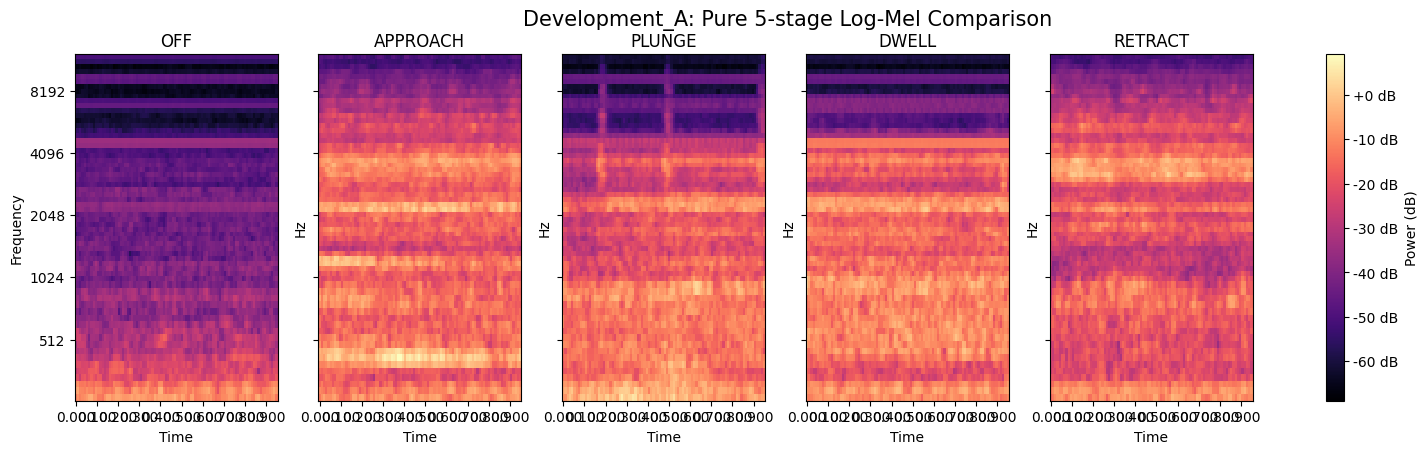

In [8]:
stage_order = [
    "off",
    "approach",
    "plunge",
    "dwell",
    "retract",
]

pure_stage_examples = []
pure_stage_mels = []

for stage_name in stage_order:
    target_column = (
        f"target_{stage_name}"
    )

    candidates = timeline_manifest[
        (
            timeline_manifest[
                "dataset_role"
            ] == "development_A"
        )
        & (
            timeline_manifest[
                target_column
            ] >= 1.0 - 1e-9
        )
    ]

    selected_row = candidates.sample(
        n=1,
        random_state=42,
    ).iloc[0]

    audio = read_audio_window(
        selected_row["relative_path"],
        selected_row[
            "window_start_sec"
        ],
    )

    log_mel = make_log_mel(audio)

    pure_stage_examples.append(
        selected_row
    )
    pure_stage_mels.append(
        log_mel
    )

    print(
        stage_name,
        "| experiment:",
        int(
            selected_row[
                "experiment_id"
            ]
        ),
        "| start:",
        selected_row[
            "window_start_sec"
        ],
        "| shape:",
        log_mel.shape,
    )

shared_vmin = min(
    mel.min()
    for mel in pure_stage_mels
)

shared_vmax = max(
    mel.max()
    for mel in pure_stage_mels
)

fig, axes = plt.subplots(
    1,
    5,
    figsize=(19, 4.5),
    sharex=True,
    sharey=True,
)

last_image = None

for axis, stage_name, log_mel in zip(
    axes,
    stage_order,
    pure_stage_mels,
):
    last_image = librosa.display.specshow(
        log_mel,
        sr=SAMPLE_RATE,
        hop_length=STFT_HOP_LENGTH,
        x_axis="time",
        y_axis="mel",
        fmin=FMIN,
        fmax=FMAX,
        vmin=shared_vmin,
        vmax=shared_vmax,
        cmap="magma",
        ax=axis,
    )

    axis.set_title(
        stage_name.upper()
    )

    axis.set_xlabel("Time")

axes[0].set_ylabel("Frequency")

fig.colorbar(
    last_image,
    ax=axes,
    format="%+2.0f dB",
    label="Power (dB)",
)

fig.suptitle(
    "Development_A: Pure 5-stage Log-Mel Comparison",
    fontsize=15,
)

plt.show()

## 다섯 종류 경계의 혼합 Log-Mel 비교

development_A에서 경계가 윈도우 중심에 가장 가까운 사례를 경계 종류별로 선택한다.

빨간 점선은 실제 stage 경계 위치를 나타낸다. 경계 전후로 음향 패턴이 어떻게 변화하는지 확인한다.

In [14]:
boundary_transitions = [
    ("off", "approach"),
    ("approach", "plunge"),
    ("plunge", "dwell"),
    ("dwell", "retract"),
    ("retract", "off"),
]

boundary_example_rows = []
boundary_example_mels = []

for from_stage, to_stage in (
    boundary_transitions
):
    candidates = timeline_manifest[
        (
            timeline_manifest[
                "dataset_role"
            ] == "development_A"
        )
        & (
            timeline_manifest[
                "boundary_present"
            ]
        )
        & (
            timeline_manifest[
                "from_stage"
            ] == from_stage
        )
        & (
            timeline_manifest[
                "to_stage"
            ] == to_stage
        )
    ].copy()

    candidates[
        "center_distance"
    ] = (
        candidates[
            "boundary_offset_sec"
        ]
        - 0.5
    ).abs()

    selected_row = (
        candidates
        .sort_values(
            [
                "center_distance",
                "experiment_id",
            ]
        )
        .iloc[0]
    )

    audio = read_audio_window(
        selected_row["relative_path"],
        selected_row[
            "window_start_sec"
        ],
    )

    log_mel = make_log_mel(audio)

    boundary_example_rows.append(
        selected_row
    )
    boundary_example_mels.append(
        log_mel
    )

    print(
        f"{from_stage} → {to_stage}",
        "| experiment:",
        int(
            selected_row[
                "experiment_id"
            ]
        ),
        "| boundary offset:",
        selected_row[
            "boundary_offset_sec"
        ],
        "| from fraction:",
        selected_row[
            f"target_{from_stage}"
        ],
        "| to fraction:",
        selected_row[
            f"target_{to_stage}"
        ],
    )



off → approach | experiment: 1 | boundary offset: 0.5 | from fraction: 0.5 | to fraction: 0.5
approach → plunge | experiment: 1 | boundary offset: 0.5099999999999998 | from fraction: 0.5099999999999998 | to fraction: 0.4900000000000002
plunge → dwell | experiment: 1 | boundary offset: 0.5100000000000016 | from fraction: 0.5100000000000016 | to fraction: 0.4899999999999984
dwell → retract | experiment: 1 | boundary offset: 0.5100000000000016 | from fraction: 0.5100000000000016 | to fraction: 0.4899999999999984
retract → off | experiment: 5 | boundary offset: 0.4969999999999999 | from fraction: 0.4969999999999999 | to fraction: 0.5030000000000001


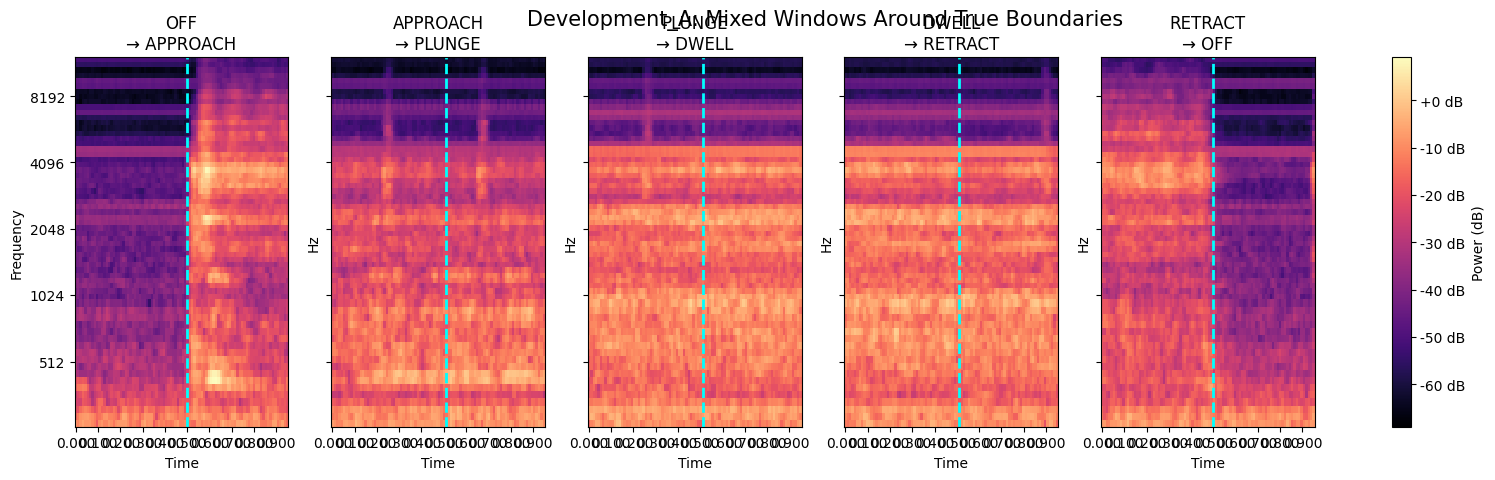

In [15]:
fig, axes = plt.subplots(
    1,
    5,
    figsize=(20, 4.8),
    sharex=True,
    sharey=True,
)

last_image = None

for (
    axis,
    transition,
    selected_row,
    log_mel,
) in zip(
    axes,
    boundary_transitions,
    boundary_example_rows,
    boundary_example_mels,
):
    from_stage, to_stage = transition

    last_image = librosa.display.specshow(
        log_mel,
        sr=SAMPLE_RATE,
        hop_length=STFT_HOP_LENGTH,
        x_axis="time",
        y_axis="mel",
        fmin=FMIN,
        fmax=FMAX,
        vmin=shared_vmin,
        vmax=shared_vmax,
        cmap="magma",
        ax=axis,
    )

    axis.axvline(
        selected_row[
            "boundary_offset_sec"
        ],
        color="cyan",
        linestyle="--",
        linewidth=2,
        label="True boundary",
    )

    axis.set_title(
        f"{from_stage.upper()}\n→ "
        f"{to_stage.upper()}"
    )

    axis.set_xlabel("Time")

axes[0].set_ylabel("Frequency")

fig.colorbar(
    last_image,
    ax=axes,
    format="%+2.0f dB",
    label="Power (dB)",
)

fig.suptitle(
    "Development_A: Mixed Windows Around True Boundaries",
    fontsize=15,
)

plt.show()

## 개발 데이터의 경계 전후 음향 특징 계산

development_A/B의 실제 경계를 기준으로 -1.5초부터 +1.5초까지 0.25초 간격으로 1초 윈도우를 생성한다.

각 윈도우에서 RMS, 평균 Log-Mel 에너지, spectral centroid와 이전 윈도우 대비 Mel 변화량을 계산한다. test_holdout은 사용하지 않는다.

In [17]:
development_boundaries = (
    timeline_manifest[
        (
            timeline_manifest[
                "dataset_role"
            ].isin(
                [
                    "development_A",
                    "development_B",
                ]
            )
        )
        & (
            timeline_manifest[
                "boundary_present"
            ]
        )
    ][
        [
            "experiment_id",
            "dataset_role",
            "relative_path",
            "boundary_index",
            "from_stage",
            "to_stage",
            "boundary_sec",
        ]
    ]
    .drop_duplicates()
    .sort_values(
        [
            "experiment_id",
            "boundary_index",
        ]
    )
    .reset_index(drop=True)
)

relative_center_times = np.arange(
    -1.5,
    1.5 + 1e-9,
    0.25,
)

boundary_feature_records = []

print(
    "개발 경계 수:",
    len(development_boundaries),
)

for experiment_id, experiment_boundaries in (
    development_boundaries.groupby(
        "experiment_id"
    )
):
    relative_path = (
        experiment_boundaries[
            "relative_path"
        ].iloc[0]
    )

    sequence_path = (
        PROJECT_DIR / relative_path
    )

    sequence_audio, sequence_sr = sf.read(
        str(sequence_path),
        dtype="float32",
        always_2d=False,
    )

    if sequence_audio.ndim == 2:
        sequence_audio = (
            sequence_audio.mean(axis=1)
        )

    if sequence_sr != SAMPLE_RATE:
        raise ValueError(
            f"{experiment_id}번 "
            "샘플링레이트 오류"
        )

    for boundary in (
        experiment_boundaries.itertuples()
    ):
        boundary_profiles = []

        for relative_center_sec in (
            relative_center_times
        ):
            window_center_sec = (
                boundary.boundary_sec
                + relative_center_sec
            )

            window_start_sec = (
                window_center_sec
                - AUDIO_WINDOW_SEC / 2
            )

            start_frame = int(
                round(
                    window_start_sec
                    * SAMPLE_RATE
                )
            )

            end_frame = (
                start_frame
                + AUDIO_WINDOW_FRAMES
            )

            audio_window = sequence_audio[
                start_frame:end_frame
            ]

            if (
                len(audio_window)
                != AUDIO_WINDOW_FRAMES
            ):
                raise ValueError(
                    f"{experiment_id}번 "
                    f"{boundary.from_stage}→"
                    f"{boundary.to_stage} "
                    "윈도우 길이 오류"
                )

            log_mel = make_log_mel(
                audio_window
            )

            mel_profile = log_mel.mean(
                axis=1
            )

            rms = np.sqrt(
                np.mean(
                    audio_window.astype(
                        np.float64
                    ) ** 2
                )
            )

            rms_db = (
                20.0
                * np.log10(
                    rms + 1e-12
                )
            )

            spectral_centroid = (
                librosa.feature
                .spectral_centroid(
                    y=audio_window,
                    sr=SAMPLE_RATE,
                    n_fft=N_FFT,
                    hop_length=(
                        STFT_HOP_LENGTH
                    ),
                    center=False,
                )
                .mean()
            )

            boundary_profiles.append({
                "experiment_id": int(
                    experiment_id
                ),
                "dataset_role": (
                    boundary.dataset_role
                ),
                "boundary_index": int(
                    boundary.boundary_index
                ),
                "from_stage": (
                    boundary.from_stage
                ),
                "to_stage": (
                    boundary.to_stage
                ),
                "relative_center_sec": float(
                    relative_center_sec
                ),
                "rms_db": float(
                    rms_db
                ),
                "mean_log_mel_db": float(
                    log_mel.mean()
                ),
                "spectral_centroid_hz": (
                    float(
                        spectral_centroid
                    )
                ),
                "mel_profile": (
                    mel_profile
                ),
            })

        previous_mel_profile = None

        for profile in boundary_profiles:
            current_mel_profile = profile[
                "mel_profile"
            ]

            if previous_mel_profile is None:
                mel_flux = np.nan
            else:
                mel_flux = float(
                    np.sqrt(
                        np.mean(
                            (
                                current_mel_profile
                                - previous_mel_profile
                            ) ** 2
                        )
                    )
                )

            output_profile = {
                key: value
                for key, value
                in profile.items()
                if key != "mel_profile"
            }

            output_profile[
                "mel_flux_db"
            ] = mel_flux

            boundary_feature_records.append(
                output_profile
            )

            previous_mel_profile = (
                current_mel_profile.copy()
            )

    print(
        f"\r경계 특징 계산: "
        f"실험 {int(experiment_id)}/18",
        end="",
    )

print()

boundary_features = pd.DataFrame(
    boundary_feature_records
)

print(
    "특징 행 수:",
    len(boundary_features),
)

print(
    "실험 수:",
    boundary_features[
        "experiment_id"
    ].nunique(),
)

print(
    "경계 종류 수:",
    boundary_features[
        [
            "from_stage",
            "to_stage",
        ]
    ]
    .drop_duplicates()
    .shape[0],
)

print(
    "경계 종류별 행 수:"
)

display(
    boundary_features.groupby(
        [
            "from_stage",
            "to_stage",
        ]
    )
    .size()
    .rename("row_count")
    .reset_index()
)

display(
    boundary_features.head()
)

개발 경계 수: 90
경계 특징 계산: 실험 18/18
특징 행 수: 1170
실험 수: 18
경계 종류 수: 5
경계 종류별 행 수:


,from_stage,to_stage,row_count
0,approach,plunge,234
1,dwell,retract,234
2,off,approach,234
3,plunge,dwell,234
4,retract,off,234


,experiment_id,dataset_role,boundary_index,from_stage,to_stage,relative_center_sec,rms_db,mean_log_mel_db,spectral_centroid_hz,mel_flux_db
0,1,development_A,0,off,approach,-1.50,-44.996505,-42.387897,2532.018310,NaN
1,1,development_A,0,off,approach,-1.25,-44.970293,-42.406635,2551.394493,0.288996
2,1,development_A,0,off,approach,-1.00,-45.179525,-42.393578,2569.765271,0.321359
3,1,development_A,0,off,approach,-0.75,-44.984996,-42.390274,2560.570794,0.326583
4,1,development_A,0,off,approach,-0.50,-45.068083,-42.362534,2580.575344,0.337811


## 경계 종류별 평균 음향 변화 시각화

18개 개발 실험의 특징을 경계 시각에 맞춰 정렬하고 평균과 표준편차를 계산한다.

세로 점선 0초가 실제 경계다. 평균 곡선이 경계 전후로 일관되게 변화하고 표준편차 범위보다 변화가 크다면 음향으로 검출할 가능성이 높다.

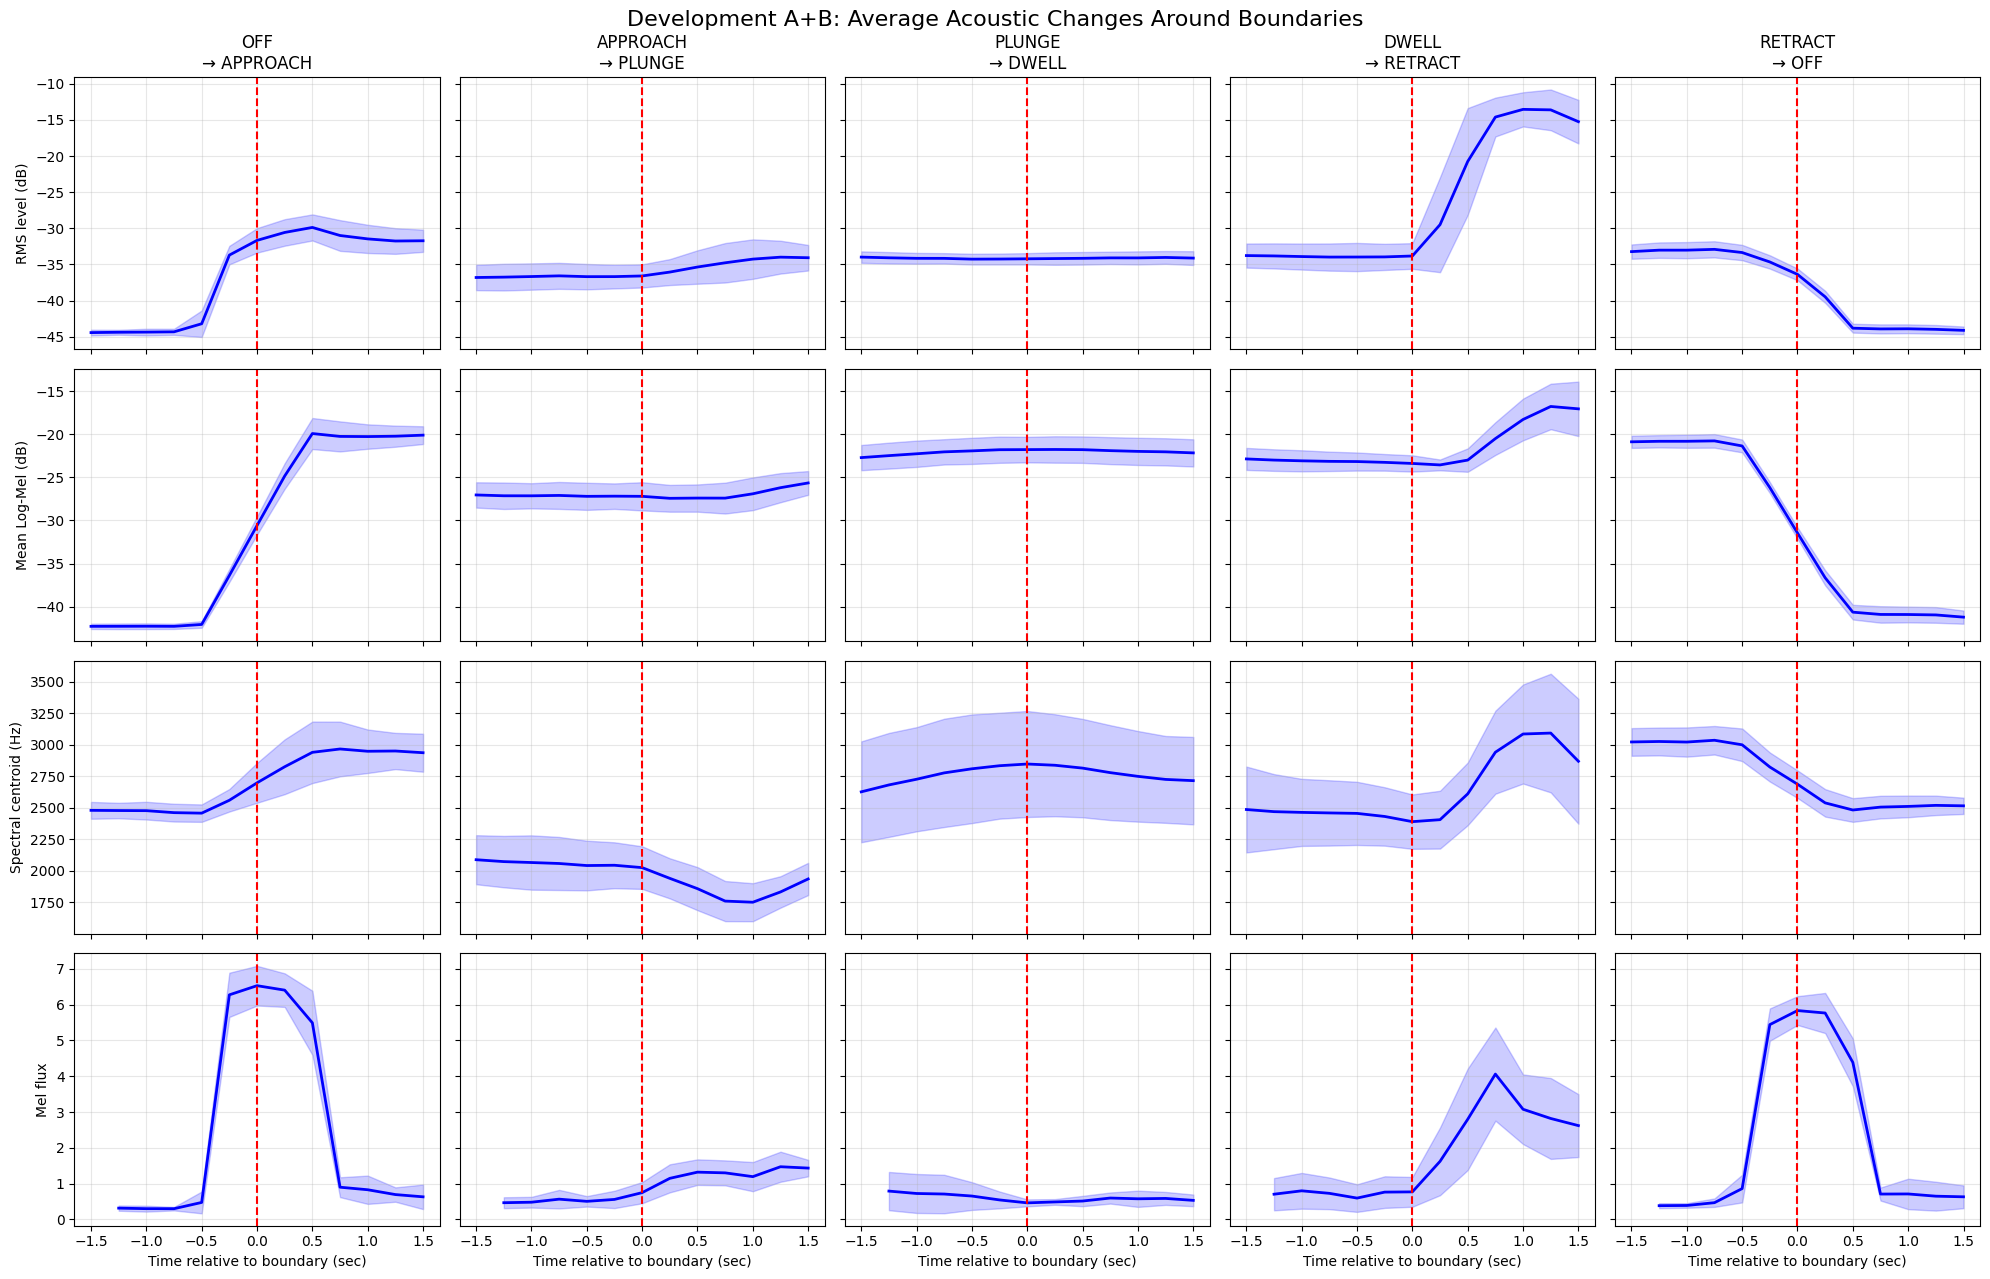

In [18]:
feature_columns = [
    (
        "rms_db",
        "RMS level (dB)",
    ),
    (
        "mean_log_mel_db",
        "Mean Log-Mel (dB)",
    ),
    (
        "spectral_centroid_hz",
        "Spectral centroid (Hz)",
    ),
    (
        "mel_flux_db",
        "Mel flux",
    ),
]

transition_order = [
    ("off", "approach"),
    ("approach", "plunge"),
    ("plunge", "dwell"),
    ("dwell", "retract"),
    ("retract", "off"),
]

fig, axes = plt.subplots(
    len(feature_columns),
    len(transition_order),
    figsize=(20, 13),
    sharex=True,
    sharey="row",
)

for row_index, (
    feature_name,
    feature_label,
) in enumerate(feature_columns):
    for column_index, (
        from_stage,
        to_stage,
    ) in enumerate(transition_order):
        axis = axes[
            row_index,
            column_index,
        ]

        transition_data = (
            boundary_features[
                (
                    boundary_features[
                        "from_stage"
                    ] == from_stage
                )
                & (
                    boundary_features[
                        "to_stage"
                    ] == to_stage
                )
            ]
        )

        summary = (
            transition_data.groupby(
                "relative_center_sec"
            )[feature_name]
            .agg(
                ["mean", "std"]
            )
            .reset_index()
        )

        x_values = summary[
            "relative_center_sec"
        ].to_numpy()

        mean_values = summary[
            "mean"
        ].to_numpy()

        std_values = summary[
            "std"
        ].fillna(0).to_numpy()

        axis.plot(
            x_values,
            mean_values,
            color="blue",
            linewidth=2,
        )

        axis.fill_between(
            x_values,
            mean_values - std_values,
            mean_values + std_values,
            color="blue",
            alpha=0.2,
        )

        axis.axvline(
            0.0,
            color="red",
            linestyle="--",
            linewidth=1.5,
        )

        axis.grid(alpha=0.3)

        if row_index == 0:
            axis.set_title(
                f"{from_stage.upper()}\n"
                f"→ {to_stage.upper()}"
            )

        if column_index == 0:
            axis.set_ylabel(
                feature_label
            )

        if row_index == (
            len(feature_columns) - 1
        ):
            axis.set_xlabel(
                "Time relative to boundary (sec)"
            )

fig.suptitle(
    "Development A+B: Average Acoustic Changes Around Boundaries",
    fontsize=16,
)

plt.tight_layout()
plt.show()
plt.close(fig)

## 5-stage Log-Mel cache 생성

타임라인의 모든 1초 윈도우를 동일한 `(64, 90)` Log-Mel spectrogram으로 변환한다.

실험과 시간 순서를 유지한 채 다음 세 파일로 분리해 저장한다.

- `development_A_5stage_logmel.npz`
- `development_B_5stage_logmel.npz`
- `test_holdout_5stage_logmel.npz`

각 cache에는 Log-Mel, stage hard/soft label, 경계 label, 경계 위치와 시계열 구성에 필요한 실험 번호 및 윈도우 순서를 함께 저장한다.

In [19]:
FIVE_STAGE_MEL_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

MEL_SHAPE = make_log_mel(
    np.zeros(
        AUDIO_WINDOW_FRAMES,
        dtype=np.float32,
    )
).shape

soft_target_columns = [
    "target_off",
    "target_approach",
    "target_plunge",
    "target_dwell",
    "target_retract",
]

print(
    "저장 폴더:",
    FIVE_STAGE_MEL_DIR,
)

print(
    "Log-Mel shape:",
    MEL_SHAPE,
)

저장 폴더: /content/drive/MyDrive/Friction Stir Spot Welding (FSSW)/[7] 5-stage mel spectrogram
Log-Mel shape: (64, 90)


## 분할별 Log-Mel 변환 및 저장

동일한 WAV 파일을 윈도우마다 다시 열지 않고 한 번만 읽은 뒤 해당 파일의 모든 윈도우를 변환한다.

윈도우 순서는 `experiment_id → window_index` 순으로 고정해 이후 GRU 시퀀스를 구성할 수 있도록 한다.

In [20]:
def build_and_save_5stage_cache(
    dataset_role,
):
    role_manifest = (
        timeline_manifest[
            timeline_manifest[
                "dataset_role"
            ] == dataset_role
        ]
        .sort_values(
            [
                "experiment_id",
                "window_index",
            ]
        )
        .reset_index(drop=True)
        .copy()
    )

    sample_count = len(
        role_manifest
    )

    X = np.empty(
        (
            sample_count,
            MEL_SHAPE[0],
            MEL_SHAPE[1],
            1,
        ),
        dtype=np.float32,
    )

    y_stage = role_manifest[
        "center_stage_id"
    ].to_numpy(
        dtype=np.int64
    )

    y_stage_soft = role_manifest[
        soft_target_columns
    ].to_numpy(
        dtype=np.float32
    )

    y_boundary = role_manifest[
        "boundary_present"
    ].to_numpy(
        dtype=np.float32
    )

    boundary_offset = (
        role_manifest[
            "boundary_offset_sec"
        ]
        .fillna(-1.0)
        .to_numpy(
            dtype=np.float32
        )
    )

    processed_count = 0

    for (
        relative_path,
        file_rows,
    ) in role_manifest.groupby(
        "relative_path",
        sort=False,
    ):
        audio_path = (
            PROJECT_DIR / relative_path
        )

        full_audio, sample_rate = sf.read(
            str(audio_path),
            dtype="float32",
            always_2d=False,
        )

        if full_audio.ndim == 2:
            full_audio = (
                full_audio.mean(axis=1)
            )

        if sample_rate != SAMPLE_RATE:
            raise ValueError(
                f"샘플링레이트 오류: "
                f"{audio_path.name}"
            )

        for row_index, row in (
            file_rows.iterrows()
        ):
            start_frame = int(
                round(
                    float(
                        row[
                            "window_start_sec"
                        ]
                    )
                    * SAMPLE_RATE
                )
            )

            end_frame = (
                start_frame
                + AUDIO_WINDOW_FRAMES
            )

            audio_window = full_audio[
                start_frame:end_frame
            ]

            if (
                len(audio_window)
                != AUDIO_WINDOW_FRAMES
            ):
                raise ValueError(
                    f"윈도우 길이 오류: "
                    f"{audio_path.name}, "
                    f"{row['window_start_sec']}초"
                )

            X[
                row_index,
                :,
                :,
                0,
            ] = make_log_mel(
                audio_window
            )

            processed_count += 1

        print(
            f"\r{dataset_role}: "
            f"{processed_count}/"
            f"{sample_count} 변환",
            end="",
        )

    print()

    output_path = (
        FIVE_STAGE_MEL_DIR
        / (
            f"{dataset_role}"
            "_5stage_logmel.npz"
        )
    )

    np.savez_compressed(
        output_path,
        X=X,
        y_stage=y_stage,
        y_stage_soft=y_stage_soft,
        y_boundary=y_boundary,
        boundary_offset=boundary_offset,
        timeline_window_id=(
            role_manifest[
                "timeline_window_id"
            ].astype(str).to_numpy()
        ),
        experiment_id=(
            role_manifest[
                "experiment_id"
            ].to_numpy(
                dtype=np.int64
            )
        ),
        window_index=(
            role_manifest[
                "window_index"
            ].to_numpy(
                dtype=np.int64
            )
        ),
        window_start_sec=(
            role_manifest[
                "window_start_sec"
            ].to_numpy(
                dtype=np.float32
            )
        ),
        center_stage=(
            role_manifest[
                "center_stage"
            ].astype(str).to_numpy()
        ),
        from_stage=(
            role_manifest[
                "from_stage"
            ].fillna("").astype(
                str
            ).to_numpy()
        ),
        to_stage=(
            role_manifest[
                "to_stage"
            ].fillna("").astype(
                str
            ).to_numpy()
        ),
    )

    stage_ids, stage_counts = np.unique(
        y_stage,
        return_counts=True,
    )

    stage_count_result = {
        ID_TO_STAGE[
            int(stage_id)
        ]: int(stage_count)
        for stage_id, stage_count
        in zip(
            stage_ids,
            stage_counts,
        )
    }

    print(
        "저장 완료:",
        output_path,
    )

    print(
        "X shape:",
        X.shape,
    )

    print(
        "Stage 개수:",
        stage_count_result,
    )

    print(
        "경계 윈도우:",
        int(y_boundary.sum()),
    )

    return output_path

## 세 데이터 분할의 cache 생성

development_A, development_B, test_holdout 순서로 변환한다. test_holdout은 저장만 하고 모델 구조 선택이나 성능 분석에는 사용하지 않는다.

In [21]:
saved_5stage_cache_paths = []

for dataset_role in [
    "development_A",
    "development_B",
    "test_holdout",
]:
    saved_path = (
        build_and_save_5stage_cache(
            dataset_role
        )
    )

    saved_5stage_cache_paths.append(
        saved_path
    )

development_A: 1752/1752 변환
저장 완료: /content/drive/MyDrive/Friction Stir Spot Welding (FSSW)/[7] 5-stage mel spectrogram/development_A_5stage_logmel.npz
X shape: (1752, 64, 90, 1)
Stage 개수: {'off': 108, 'approach': 459, 'plunge': 243, 'dwell': 252, 'retract': 690}
경계 윈도우: 171
development_B: 1754/1754 변환
저장 완료: /content/drive/MyDrive/Friction Stir Spot Welding (FSSW)/[7] 5-stage mel spectrogram/development_B_5stage_logmel.npz
X shape: (1754, 64, 90, 1)
Stage 개수: {'off': 108, 'approach': 459, 'plunge': 243, 'dwell': 252, 'retract': 692}
경계 윈도우: 171
test_holdout: 1754/1754 변환
저장 완료: /content/drive/MyDrive/Friction Stir Spot Welding (FSSW)/[7] 5-stage mel spectrogram/test_holdout_5stage_logmel.npz
X shape: (1754, 64, 90, 1)
Stage 개수: {'off': 108, 'approach': 459, 'plunge': 243, 'dwell': 252, 'retract': 692}
경계 윈도우: 171


## PyTorch 환경과 개발 cache 불러오기

development_A와 development_B만 불러온다.

첫 번째 교차검증에서는 A를 학습 데이터로, B를 검증 데이터로 사용한다. test_holdout은 최종 모델이 결정될 때까지 불러오지 않는다.

In [22]:
import torch
import torch.nn as nn

from torch.utils.data import (
    DataLoader,
    TensorDataset,
)

torch.manual_seed(42)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(
    "사용 장치:",
    device,
)

development_a_cache = np.load(
    FIVE_STAGE_MEL_DIR
    / "development_A_5stage_logmel.npz"
)

development_b_cache = np.load(
    FIVE_STAGE_MEL_DIR
    / "development_B_5stage_logmel.npz"
)

X_a = development_a_cache["X"]
y_stage_a = development_a_cache[
    "y_stage"
]
y_soft_a = development_a_cache[
    "y_stage_soft"
]
y_boundary_a = development_a_cache[
    "y_boundary"
]

X_b = development_b_cache["X"]
y_stage_b = development_b_cache[
    "y_stage"
]
y_soft_b = development_b_cache[
    "y_stage_soft"
]
y_boundary_b = development_b_cache[
    "y_boundary"
]

print(
    "development_A:",
    X_a.shape,
)

print(
    "development_B:",
    X_b.shape,
)

print(
    "A 경계 윈도우:",
    int(y_boundary_a.sum()),
)

print(
    "B 경계 윈도우:",
    int(y_boundary_b.sum()),
)

사용 장치: cuda
development_A: (1752, 64, 90, 1)
development_B: (1754, 64, 90, 1)
A 경계 윈도우: 171
B 경계 윈도우: 171


## 첫 번째 교차검증 정규화

학습 분할인 development_A에서만 전체 평균과 표준편차를 계산한다.

같은 값을 development_B에 적용해 검증 데이터의 통계정보가 학습에 유입되지 않도록 한다.

In [23]:
train_mean_fold_1 = X_a.mean(
    dtype=np.float64
)

train_std_fold_1 = X_a.std(
    dtype=np.float64
)

X_train_fold_1 = (
    (
        X_a - train_mean_fold_1
    )
    / train_std_fold_1
).astype(np.float32)

X_valid_fold_1 = (
    (
        X_b - train_mean_fold_1
    )
    / train_std_fold_1
).astype(np.float32)

print(
    "학습 평균:",
    train_mean_fold_1,
)

print(
    "학습 표준편차:",
    train_std_fold_1,
)

print(
    "정규화 후 평균:",
    X_train_fold_1.mean(),
)

print(
    "정규화 후 표준편차:",
    X_train_fold_1.std(),
)

학습 평균: -24.215343295948387
학습 표준편차: 15.584174597557935
정규화 후 평균: 6.9674835e-09
정규화 후 표준편차: 1.0000001


## 클래스 가중치 계산

OFF, Plunge와 Dwell은 Approach 및 Retract보다 윈도우 수가 적다.

학습 데이터 A의 hard label 개수로 클래스 가중치를 계산해 적은 stage의 오분류가 학습 손실에 더 크게 반영되도록 한다.

In [24]:
stage_counts_fold_1 = np.bincount(
    y_stage_a,
    minlength=5,
)

class_weights_fold_1 = (
    len(y_stage_a)
    / (
        5.0
        * stage_counts_fold_1
    )
).astype(np.float32)

print(
    "Stage 개수:",
    {
        ID_TO_STAGE[index]: int(count)
        for index, count
        in enumerate(
            stage_counts_fold_1
        )
    },
)

print(
    "클래스 가중치:",
    {
        ID_TO_STAGE[index]: float(weight)
        for index, weight
        in enumerate(
            class_weights_fold_1
        )
    },
)

Stage 개수: {'off': 108, 'approach': 459, 'plunge': 243, 'dwell': 252, 'retract': 690}
클래스 가중치: {'off': 3.2444443702697754, 'approach': 0.7633987069129944, 'plunge': 1.4419753551483154, 'dwell': 1.3904762268066406, 'retract': 0.5078260898590088}


## PyTorch Tensor와 DataLoader 구성

PyTorch CNN 입력 형식에 맞게 `(N, 64, 90, 1)`을 `(N, 1, 64, 90)`으로 변경한다.

hard label은 평가에 사용하고, stage 포함 비율인 soft label은 학습 손실 계산에 사용한다.

In [25]:
def make_stage_dataset(
    X,
    y_stage,
    y_soft,
    y_boundary,
):
    X_tensor = torch.from_numpy(
        X
    ).permute(
        0, 3, 1, 2
    )

    y_stage_tensor = torch.from_numpy(
        y_stage
    ).long()

    y_soft_tensor = torch.from_numpy(
        y_soft
    ).float()

    y_boundary_tensor = torch.from_numpy(
        y_boundary
    ).float()

    return TensorDataset(
        X_tensor,
        y_stage_tensor,
        y_soft_tensor,
        y_boundary_tensor,
    )


train_dataset_fold_1 = (
    make_stage_dataset(
        X_train_fold_1,
        y_stage_a,
        y_soft_a,
        y_boundary_a,
    )
)

valid_dataset_fold_1 = (
    make_stage_dataset(
        X_valid_fold_1,
        y_stage_b,
        y_soft_b,
        y_boundary_b,
    )
)

train_loader_fold_1 = DataLoader(
    train_dataset_fold_1,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=(
        device.type == "cuda"
    ),
)

valid_loader_fold_1 = DataLoader(
    valid_dataset_fold_1,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=(
        device.type == "cuda"
    ),
)

print(
    "학습 Tensor:",
    train_dataset_fold_1.tensors[0].shape,
)

print(
    "검증 Tensor:",
    valid_dataset_fold_1.tensors[0].shape,
)

학습 Tensor: torch.Size([1752, 1, 64, 90])
검증 Tensor: torch.Size([1754, 1, 64, 90])


## 5-stage 기준 CNN 정의

각 1초 Log-Mel을 독립적으로 입력받아 다섯 stage 점수를 출력한다.

이 모델은 윈도우 사이의 시간 순서를 사용하지 않으며, 이후 CNN+GRU 모델의 개선 효과를 비교하기 위한 기준 모델이다.

In [26]:
import copy

import torch.nn.functional as F

from sklearn.metrics import (
    f1_score,
)


class FiveStageCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(
                1,
                16,
                kernel_size=3,
                padding=1,
            ),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(
                16,
                32,
                kernel_size=3,
                padding=1,
            ),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(
                32,
                64,
                kernel_size=3,
                padding=1,
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(),
        )

        self.pool = nn.AdaptiveAvgPool2d(
            (1, 1)
        )

        self.dropout = nn.Dropout(0.3)

        self.classifier = nn.Linear(
            64,
            5,
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = torch.flatten(
            x,
            start_dim=1,
        )
        x = self.dropout(x)
        logits = self.classifier(x)

        return logits


torch.manual_seed(42)

model_cnn_fold_1 = (
    FiveStageCNN().to(device)
)

parameter_count = sum(
    parameter.numel()
    for parameter
    in model_cnn_fold_1.parameters()
    if parameter.requires_grad
)

print(model_cnn_fold_1)

print(
    "학습 가능 파라미터:",
    parameter_count,
)

FiveStageCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
  )
  (pool): AdaptiveAvgPool2d(output_size=(1, 1))
  (dropout): Dropout(p=0.3, inplace=False)
  (classifier): Linear(in_features=64, out_features=5, bias=True)
)
학습 가능 파라미터: 23845


## 클래스 가중 Soft-label 손실 함수

순수 윈도우에는 one-hot label을, 경계 혼합 윈도우에는 stage 포함 비율을 정답으로 사용한다.

학습 데이터에서 적은 stage가 무시되지 않도록 development_A에서 계산한 클래스 가중치를 적용한다.

In [27]:
class_weight_tensor_fold_1 = (
    torch.tensor(
        class_weights_fold_1,
        dtype=torch.float32,
        device=device,
    )
)


def weighted_soft_cross_entropy(
    logits,
    soft_targets,
    class_weights,
):
    log_probabilities = (
        F.log_softmax(
            logits,
            dim=1,
        )
    )

    weighted_targets = (
        soft_targets
        * class_weights.unsqueeze(0)
    )

    sample_losses = -(
        weighted_targets
        * log_probabilities
    ).sum(dim=1)

    return sample_losses.mean()

## CNN 학습 및 평가 함수

전체 stage 정확도와 Macro F1을 계산한다.

경계를 포함하지 않는 순수 윈도우와 경계를 포함하는 혼합 윈도우의 stage 정확도를 별도로 측정해 모델이 경계에서 얼마나 약해지는지 확인한다.

In [28]:
def run_cnn_stage_epoch(
    model,
    data_loader,
    class_weights,
    optimizer=None,
):
    is_training = (
        optimizer is not None
    )

    if is_training:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    all_labels = []
    all_predictions = []
    all_boundary_flags = []

    for (
        batch_X,
        batch_hard_labels,
        batch_soft_labels,
        batch_boundary_flags,
    ) in data_loader:
        batch_X = batch_X.to(
            device,
            non_blocking=True,
        )

        batch_hard_labels = (
            batch_hard_labels.to(
                device,
                non_blocking=True,
            )
        )

        batch_soft_labels = (
            batch_soft_labels.to(
                device,
                non_blocking=True,
            )
        )

        if is_training:
            optimizer.zero_grad()

        with torch.set_grad_enabled(
            is_training
        ):
            logits = model(batch_X)

            loss = (
                weighted_soft_cross_entropy(
                    logits,
                    batch_soft_labels,
                    class_weights,
                )
            )

            if is_training:
                loss.backward()
                optimizer.step()

        predictions = logits.argmax(
            dim=1
        )

        total_loss += (
            loss.item()
            * batch_X.size(0)
        )

        all_labels.extend(
            batch_hard_labels
            .detach()
            .cpu()
            .numpy()
        )

        all_predictions.extend(
            predictions
            .detach()
            .cpu()
            .numpy()
        )

        all_boundary_flags.extend(
            batch_boundary_flags
            .numpy()
        )

    labels = np.asarray(
        all_labels
    )

    predictions = np.asarray(
        all_predictions
    )

    boundary_flags = (
        np.asarray(
            all_boundary_flags
        ).astype(bool)
    )

    accuracy = np.mean(
        labels == predictions
    )

    macro_f1 = f1_score(
        labels,
        predictions,
        average="macro",
    )

    interior_mask = (
        ~boundary_flags
    )

    boundary_accuracy = np.mean(
        labels[boundary_flags]
        == predictions[boundary_flags]
    )

    interior_accuracy = np.mean(
        labels[interior_mask]
        == predictions[interior_mask]
    )

    return {
        "loss": (
            total_loss
            / len(data_loader.dataset)
        ),
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "interior_accuracy": (
            interior_accuracy
        ),
        "boundary_accuracy": (
            boundary_accuracy
        ),
    }

## 첫 번째 CNN 교차검증 학습

development_A로 학습하고 development_B로 검증한다.

검증 손실이 개선되지 않으면 학습률을 낮추고, 6회 연속 개선되지 않으면 학습을 중단한 뒤 가장 좋은 모델을 복원한다.

In [29]:
optimizer_cnn_fold_1 = (
    torch.optim.Adam(
        model_cnn_fold_1.parameters(),
        lr=1e-3,
        weight_decay=1e-4,
    )
)

scheduler_cnn_fold_1 = (
    torch.optim.lr_scheduler
    .ReduceLROnPlateau(
        optimizer_cnn_fold_1,
        mode="min",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
    )
)

history_cnn_fold_1 = {
    "train_loss": [],
    "valid_loss": [],
    "train_accuracy": [],
    "valid_accuracy": [],
    "valid_macro_f1": [],
    "valid_interior_accuracy": [],
    "valid_boundary_accuracy": [],
}

best_valid_loss = float("inf")
best_model_state = None
epochs_without_improvement = 0

MAX_EPOCHS = 40
EARLY_STOPPING_PATIENCE = 6

for epoch in range(
    1,
    MAX_EPOCHS + 1,
):
    train_metrics = (
        run_cnn_stage_epoch(
            model_cnn_fold_1,
            train_loader_fold_1,
            class_weight_tensor_fold_1,
            optimizer_cnn_fold_1,
        )
    )

    valid_metrics = (
        run_cnn_stage_epoch(
            model_cnn_fold_1,
            valid_loader_fold_1,
            class_weight_tensor_fold_1,
        )
    )

    scheduler_cnn_fold_1.step(
        valid_metrics["loss"]
    )

    history_cnn_fold_1[
        "train_loss"
    ].append(
        train_metrics["loss"]
    )

    history_cnn_fold_1[
        "valid_loss"
    ].append(
        valid_metrics["loss"]
    )

    history_cnn_fold_1[
        "train_accuracy"
    ].append(
        train_metrics["accuracy"]
    )

    history_cnn_fold_1[
        "valid_accuracy"
    ].append(
        valid_metrics["accuracy"]
    )

    history_cnn_fold_1[
        "valid_macro_f1"
    ].append(
        valid_metrics["macro_f1"]
    )

    history_cnn_fold_1[
        "valid_interior_accuracy"
    ].append(
        valid_metrics[
            "interior_accuracy"
        ]
    )

    history_cnn_fold_1[
        "valid_boundary_accuracy"
    ].append(
        valid_metrics[
            "boundary_accuracy"
        ]
    )

    current_lr = (
        optimizer_cnn_fold_1
        .param_groups[0]["lr"]
    )

    print(
        f"Epoch {epoch:02d} | "
        f"train loss "
        f"{train_metrics['loss']:.4f} | "
        f"train acc "
        f"{train_metrics['accuracy']:.4f} | "
        f"val loss "
        f"{valid_metrics['loss']:.4f} | "
        f"val acc "
        f"{valid_metrics['accuracy']:.4f} | "
        f"macro F1 "
        f"{valid_metrics['macro_f1']:.4f} | "
        f"interior "
        f"{valid_metrics['interior_accuracy']:.4f} | "
        f"boundary "
        f"{valid_metrics['boundary_accuracy']:.4f} | "
        f"lr {current_lr:.1e}"
    )

    if (
        valid_metrics["loss"]
        < best_valid_loss - 1e-6
    ):
        best_valid_loss = (
            valid_metrics["loss"]
        )

        best_model_state = copy.deepcopy(
            model_cnn_fold_1.state_dict()
        )

        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if (
        epochs_without_improvement
        >= EARLY_STOPPING_PATIENCE
    ):
        print(
            "Early stopping:",
            epoch,
        )
        break

model_cnn_fold_1.load_state_dict(
    best_model_state
)

print(
    "최저 검증 손실:",
    round(
        best_valid_loss,
        6,
    ),
)

Epoch 01 | train loss 1.1401 | train acc 0.4521 | val loss 1.2390 | val acc 0.4829 | macro F1 0.3571 | interior 0.4991 | boundary 0.3333 | lr 1.0e-03
Epoch 02 | train loss 0.7697 | train acc 0.6815 | val loss 1.0710 | val acc 0.5422 | macro F1 0.5181 | interior 0.5660 | boundary 0.3216 | lr 1.0e-03
Epoch 03 | train loss 0.5729 | train acc 0.7631 | val loss 1.0397 | val acc 0.5621 | macro F1 0.5106 | interior 0.5850 | boundary 0.3509 | lr 1.0e-03
Epoch 04 | train loss 0.4732 | train acc 0.8373 | val loss 0.8962 | val acc 0.6129 | macro F1 0.5993 | interior 0.6418 | boundary 0.3450 | lr 1.0e-03
Epoch 05 | train loss 0.4050 | train acc 0.8670 | val loss 1.0762 | val acc 0.5656 | macro F1 0.5105 | interior 0.5875 | boundary 0.3626 | lr 1.0e-03
Epoch 06 | train loss 0.3633 | train acc 0.8801 | val loss 0.8790 | val acc 0.7041 | macro F1 0.6852 | interior 0.7397 | boundary 0.3743 | lr 1.0e-03
Epoch 07 | train loss 0.3160 | train acc 0.8973 | val loss 0.9159 | val acc 0.5673 | macro F1 0.5256

### 현재 학습된 CNN 모델 확인

앞선 학습 셀에서 사용한 PyTorch 모델의 변수 이름을 확인한다.

노트북 메모리에 존재하는 `nn.Module` 객체를 검색하고, 이후 성능 분석에서 사용할 모델을 `evaluation_model`로 지정한다.

In [31]:
available_models = {
    name: value
    for name, value in globals().items()
    if isinstance(value, nn.Module)
}

print("현재 메모리에 존재하는 PyTorch 모델:")

for name, value in available_models.items():
    print(f"- {name}: {value.__class__.__name__}")

if len(available_models) == 0:
    raise RuntimeError(
        "현재 메모리에 학습된 PyTorch 모델이 없습니다. "
        "CNN 모델 생성 및 학습 셀을 먼저 실행해야 합니다."
    )

preferred_model_names = [
    "cnn_model",
    "best_model",
    "stage_model",
    "model"
]

evaluation_model = None
selected_model_name = None

for name in preferred_model_names:
    if name in available_models:
        evaluation_model = available_models[name]
        selected_model_name = name
        break

if evaluation_model is None:
    selected_model_name = list(
        available_models.keys()
    )[-1]

    evaluation_model = available_models[
        selected_model_name
    ]

evaluation_model = evaluation_model.to(device)
evaluation_model.eval()

print(
    "\n성능 분석에 사용할 모델:",
    selected_model_name
)

현재 메모리에 존재하는 PyTorch 모델:
- model_cnn_fold_1: FiveStageCNN

성능 분석에 사용할 모델: model_cnn_fold_1


## CNN 기준 모델의 stage별 성능 분석

현재 CNN 모델이 어떤 공정 단계를 잘 구분하고, 어떤 단계끼리 혼동하는지 확인한다.

`development_A`로 학습하고 `development_B`로 검증한 최적 모델을 사용한다. 아직 GRU는 적용하지 않았으므로 각 1초 윈도우는 서로 독립적으로 분류된다.

다음 결과를 확인한다.

- **Precision**: 특정 stage라고 예측한 결과 중 실제로 해당 stage였던 비율
- **Recall**: 실제 특정 stage 윈도우 중 모델이 올바르게 찾아낸 비율
- **F1-score**: Precision과 Recall을 함께 반영한 점수
- **Confusion Matrix**: 실제 stage가 어떤 다른 stage로 잘못 분류됐는지 나타낸 행렬

왼쪽 혼동행렬은 윈도우 개수를 나타내고, 오른쪽 혼동행렬은 각 실제 stage를 기준으로 정규화한 비율을 나타낸다.

이 결과는 CNN+GRU 모델을 적용하기 전 CNN 기준 성능으로 사용한다.

In [32]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report
)
import seaborn as sns

stage_names = [
    "OFF",
    "APPROACH",
    "PLUNGE",
    "DWELL",
    "RETRACT"
]

evaluation_model.eval()

all_true = []
all_pred = []
all_boundary = []

with torch.no_grad():
    for batch in valid_loader:
        (
            X_batch,
            y_hard_batch,
            y_soft_batch,
            y_boundary_batch
        ) = batch

        X_batch = X_batch.to(device)

        logits = evaluation_model(X_batch)
        predictions = logits.argmax(dim=1)

        all_true.extend(
            y_hard_batch.cpu().numpy()
        )
        all_pred.extend(
            predictions.cpu().numpy()
        )
        all_boundary.extend(
            y_boundary_batch.cpu().numpy()
        )

all_true = np.asarray(all_true)
all_pred = np.asarray(all_pred)
all_boundary = np.asarray(
    all_boundary
).astype(bool)

print("Development B 전체 검증 결과\n")

print(
    classification_report(
        all_true,
        all_pred,
        labels=range(5),
        target_names=stage_names,
        digits=4,
        zero_division=0
    )
)

cm = confusion_matrix(
    all_true,
    all_pred,
    labels=range(5)
)

cm_normalized = confusion_matrix(
    all_true,
    all_pred,
    labels=range(5),
    normalize="true"
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 5)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=stage_names,
    yticklabels=stage_names,
    ax=axes[0]
)

axes[0].set_title(
    "Confusion Matrix: Window Count"
)
axes[0].set_xlabel("Predicted Stage")
axes[0].set_ylabel("True Stage")

sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    vmin=0,
    vmax=1,
    xticklabels=stage_names,
    yticklabels=stage_names,
    ax=axes[1]
)

axes[1].set_title(
    "Confusion Matrix: Row Normalized"
)
axes[1].set_xlabel("Predicted Stage")
axes[1].set_ylabel("True Stage")

plt.tight_layout()
plt.show()

NameError: name 'valid_loader' is not defined